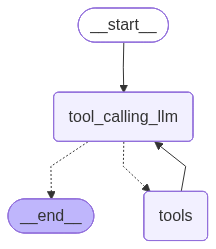

In [17]:
from langchain_openai import ChatOpenAI
from langchain.chat_models import init_chat_model
llm=ChatOpenAI()

from langchain_tavily import TavilySearch
tool=TavilySearch(max_result=2)

def multiply(a:int,b:int)->int:
    """Multiple a and b
    Args:
        a (int):first number
        b (int):second number
        
    Returns:
        int: output int
    """
    return a*b

tools=[tool,multiply]

llm_with_tool=llm.bind_tools(tools)

from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.graph.message import add_messages
from typing_extensions import TypedDict
from typing import Annotated


class State(TypedDict):
    messages:Annotated[list,add_messages]

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)
builder.add_edge("tools","tool_calling_llm")

graph=builder.compile()

from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
response

{'messages': [HumanMessage(content='Give me the recent ai news and then multiply 5 by 10', additional_kwargs={}, response_metadata={}, id='d13deda5-8e7f-4006-adfe-1dad7f5330a8'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 1307, 'total_tokens': 1376, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DYR2GiaCI6jM1DZqXUX4ocIkb4T6v', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dc361-9f77-70f3-813f-8efbae3c0e2f-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'search_depth': 'advanced', 'topic': 'news', 'include_images': False, 'time_range': 'week'}, 'id': 'call_